## Mall Customers Segmentation 


## Objective
Perform customer segmentation using:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Dimensionality Reduction (PCA)
- Clustering (KMeans)
- Evaluation using Silhouette Score


In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [15]:

# Load dataset
df = pd.read_csv('data/Mall_Customers.csv')

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:

# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [17]:

# Check missing values
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Data Preprocessing

In [18]:

# Select numerical features
data = df.select_dtypes(include=['int64', 'float64'])

# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)


## Dimensionality Reduction (PCA)

In [19]:

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.49477783 0.33144344]


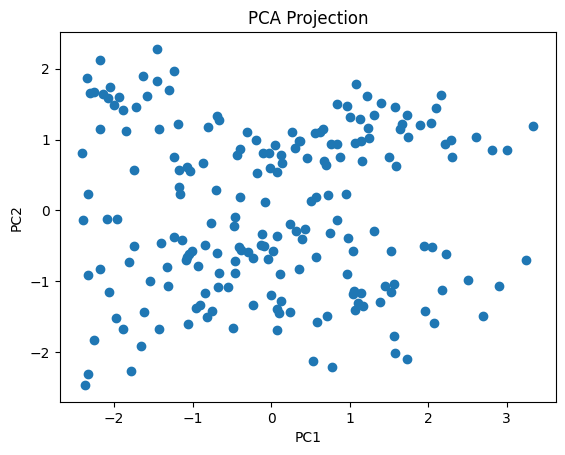

In [20]:

# Visualize PCA result
plt.scatter(pca_data[:,0], pca_data[:,1])
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Finding Optimal K (Elbow + Silhouette)

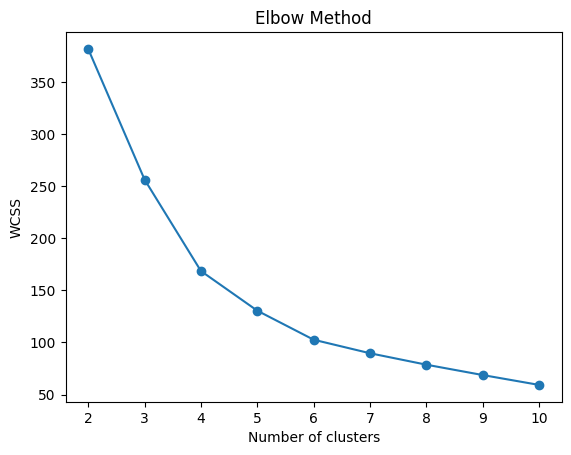

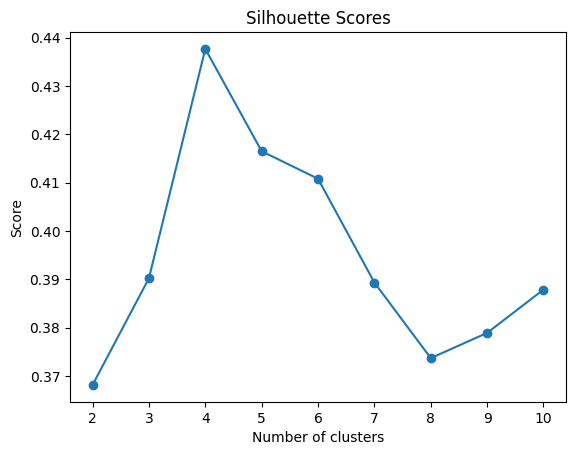

In [21]:

wcss = []
sil_scores = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(pca_data, labels))

# Elbow plot
plt.plot(range(2,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# Silhouette plot
plt.plot(range(2,11), sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.show()


## KMeans Clustering

In [24]:

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_data)

df['Cluster'] = clusters
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [25]:

# Final Silhouette Score
score = silhouette_score(pca_data, clusters)
print("Final Silhouette Score:", score)


Final Silhouette Score: 0.41649555176989084


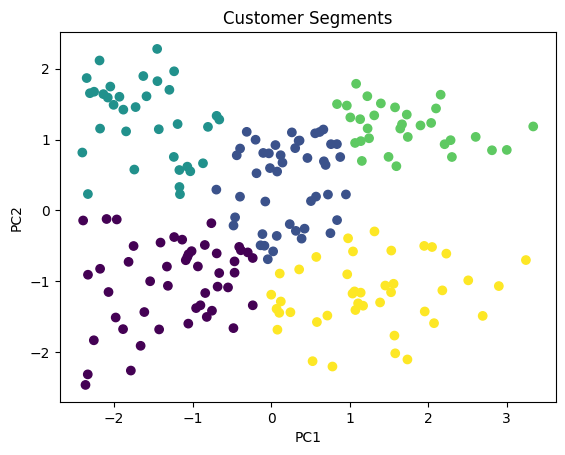

In [26]:

# Visualize clusters
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters)
plt.title("Customer Segments")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Insights


- Used Silhouette Score to validate clustering quality
- Higher score indicates well-separated clusters
- Combined with elbow method for better decision on K
